In [19]:
import time
from pathlib import Path

import requests
import xarray as xr

In [20]:
file = 'https://darchive.mblwhoilibrary.org/bitstreams/733114e0-85ef-40f0-ae43-3f647bcdcf06/download'

In [21]:
local_file = Path("whoi_download.nc")
if local_file.exists() and local_file.stat().st_size == 0:
    local_file.unlink()

if not local_file.exists():
    local_file.parent.mkdir(parents=True, exist_ok=True)
    tmp_file = local_file.with_suffix(local_file.suffix + ".part")

    for attempt in range(1, 6):
        try:
            if tmp_file.exists():
                tmp_file.unlink()

            with requests.get(
                file,
                stream=True,
                timeout=60,
                headers={"User-Agent": "Mozilla/5.0"},
            ) as response:
                response.raise_for_status()
                with tmp_file.open("wb") as out:
                    for chunk in response.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            out.write(chunk)

            tmp_file.replace(local_file)
            break
        except requests.RequestException:
            if attempt == 5:
                raise
            time.sleep(2 * attempt)

df = xr.open_dataset(local_file)
df

<xarray.Dataset> Size: 736MB
Dimensions:            (length_t: 102, single: 1, nt: 1958, nz: 5223)
Dimensions without coordinates: length_t, single, nt, nz
Data variables:
    title              (length_t, single) |S1 102B ...
    date               (single, nt) float64 16kB ...
    pgrid              (nz, single) float64 42kB ...
    disp               (nz, nt) float64 82MB ...
    nan_mask_all_ctd   (nz, nt) float64 82MB ...
    nan_mask_disp      (nz, nt) float64 82MB ...
    nan_mask_time_ctd  (nz, nt) float64 82MB ...
    S                  (nz, nt) float64 82MB ...
    T                  (nz, nt) float64 82MB ...
    TIME               (nz, nt) float64 82MB ...
    U                  (nz, nt) float64 82MB ...
    V                  (nz, nt) float64 82MB ...

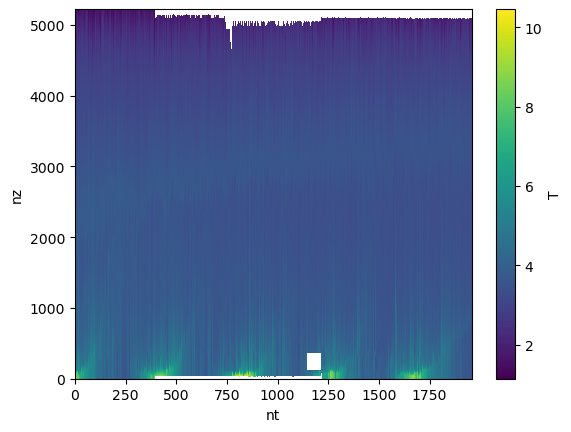

In [24]:
df['T'].plot()

In [39]:
title = b"".join(df["title"].values.ravel()).decode("utf-8", errors="ignore").strip()
print(title)

Ocean water property and velocity profile data from the Irminger Sea Ocean Observatory Initiative site
